In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from math import pi, sqrt

## Constants

In [2]:
# param
ODE_SOLVE_METHOD = 'RK45'  # 'Radau', 'BDF', 'LSODA', 'RK45', etc.

# --- Physical constants ---
h = 6.62607015e-34        # Planck constant, J·s
e_charge = 1.602176634e-19  # Elementary charge, C
hbar = h / (2 * np.pi)    # Reduced Planck constant, J·s
k_B = 1.380649e-23        # Boltzmann constant, J/K
c = 299792458.0           # Speed of light, m/s
amu = 1.66053906660e-27   # Atomic mass unit, kg

# --- Transition parameters ---
f_S12_to_P12 = 377.107463380e12        # Hz
f_S12F1_to_S12 = 4.271676631815181e9  # Hz
f_S12F1_to_S12F2 = 6.834682610904290e9  # Hz
f_P12F1_to_P12 = 509.06e6           # Hz
f_p12F1_to_P12F2 = 814.5e6          # Hz

f_S12_to_P32 = 384.2304844685e12
# f_S12F1_to_S12 = 4.271676631815181e9
f_P32F0_to_P32 = 302.0738e6
f_P32F0_to_P32F1 = 72.2180e6
f_P32F1_to_P32F2 = 156.9470e6
f_P32F2_to_P32F3 = 266.6500e6

#----------------------ASSUMPTION--------------------
# extra multiplicative term from matching my derivation with einstein B convention, should be 3, but nonexistent (1) in the reference
S_CONVENTION_CORRECTION = 3 # 3 or 3/2pi
# for lines that interact with both D1 and D2, we take the D2 Gamma_tr value since pump>>probe
#----------------------------------------------------

# note that D1x is the transition from S1/2 F=1 to P1/2 F'=x
# and D2x is the transition from S1/2 F=1 to P3/2 F'=x

# Central transition frequency: S1/2 F=1 → P1/2 F'=1
f_D11 = f_S12_to_P12 + f_S12F1_to_S12 - f_P12F1_to_P12
f_D12 = f_D11 + f_p12F1_to_P12F2
f_D20 = f_S12_to_P32 + f_S12F1_to_S12 - f_P32F0_to_P32
f_D21 = f_D20 + f_P32F0_to_P32F1
f_D22 = f_D21 + f_P32F1_to_P32F2
f_D23 = f_D22 + f_P32F2_to_P32F3

# all the f_d can be found using f_d = f_0 - delta_f_d
# delta_f_d = f_S12F1_to_S12F2

# Wavelength
lambda_D11 = c / f_D11
lambda_D12 = c / f_D12
lambda_D20 = c / f_D20
lambda_D21 = c / f_D21
lambda_D22 = c / f_D22
lambda_D23 = c / f_D23


# Linewidth (Γ_D1)
Gamma_D2 = 6.0666e6  # Hz
Gamma_D1 = 5.7500e6  # Hz

# S_ij coefficients for Einstein B calculation with ground i and excited j
S_coeff_D1_22 = 1/2
S_coeff_D1_21 = 1/2
S_coeff_D1_12 = 5/6
S_coeff_D1_11 = 1/6

S_coeff_D2_32 = 0
S_coeff_D2_23 = 7/10
S_coeff_D2_22 = 1/4
S_coeff_D2_21 = 1/20
S_coeff_D2_12 = 5/12
S_coeff_D2_11 = 5/12
S_coeff_D2_10 = 1/6
S_coeff_D2_01 = 0

# Peak cross-section (sigma_0)
sigma_D11_0 = 3 * lambda_D11**2 / (2 * np.pi)
sigma_D12_0 = 3 * lambda_D12**2 / (2 * np.pi)

sigma_D20_0 = 3 * lambda_D20**2 / (2 * np.pi)
sigma_D21_0 = 3 * lambda_D21**2 / (2 * np.pi)
sigma_D22_0 = 3 * lambda_D22**2 / (2 * np.pi)
sigma_D23_0 = 3 * lambda_D23**2 / (2 * np.pi)

# Rubidium-87 mass
m_Rb87 = 86.909180527 * amu

# Rb vapor number density (low-pressure) (assumed)
T = 273.15 + 30 # K
if(T < 273.15 + 39.31): # is solid
    log10_P_Torr = -94.04826 -1961.258 / T - 0.03771687 * T + 42.57526 * np.log10(T)
else:
    log10_P_Torr = 15.88253 - 4529.635 / T + 5.8663e-4 * T - 2.99138 * np.log10(T)
P_Torr = 10**log10_P_Torr
P_Pa = P_Torr * 133.322368  # Pa
N = 0.2783 * P_Pa / (k_B * T)  # ideal gas law, m^-3
print(f"Rb-87 vapor number density N = {N/1e16:.2f} x10^16 m^-3 at T = {T:.2f} K")

# Temperature and Doppler parameter
u = np.sqrt(2 * k_B * T / m_Rb87)

# Saturation and pump intensities
I_sat_D11 = h * f_D11 * Gamma_D1 / (2 * sigma_D11_0)
I_sat_D12 = h * f_D12 * Gamma_D1 / (2 * sigma_D12_0)
I_pu_D1 = I_sat_D11  # set equal I_sat_D11
print(f"I_pu_D1 = {I_pu_D1/10:.2f} mW/cm^2 I_sat_D11 = {I_sat_D11/10:.2f} mW/cm^2")

I_sat_D20 = h * f_D20 * Gamma_D2 / (2 * sigma_D20_0)
I_sat_D21 = h * f_D21 * Gamma_D2 / (2 * sigma_D21_0)
I_sat_D22 = h * f_D22 * Gamma_D2 / (2 * sigma_D22_0)
I_sat_D23 = h * f_D23 * Gamma_D2 / (2 * sigma_D23_0)
I_pu_D2 = I_sat_D21  # set equal I_sat_D20
print(f"I_pu_D2 = {I_pu_D2/10:.2f} mW/cm^2 I_sat_D21 = {I_sat_D21/10:.2f} mW/cm^2")

# beam waist diameter
D_D1 = 0.8e-3  # 0.8 mm
D_D2 = 1.5e-3  # 1.5 mm
Gamma_tr_D1 = 1.13 * u/D_D1  # transit-time broadening
Gamma_tr_D2 = 1.13 * u/D_D2  # transit-time broadening
print(f"Transit-time broadening Gamma_tr_D1 = {Gamma_tr_D1/1e6:.2f} MHz")
print(f"Transit-time broadening Gamma_tr_D2 = {Gamma_tr_D2/1e6:.2f} MHz")


Rb-87 vapor number density N = 0.45 x10^16 m^-3 at T = 303.15 K
I_pu_D1 = 0.24 mW/cm^2 I_sat_D11 = 0.24 mW/cm^2
I_pu_D2 = 0.27 mW/cm^2 I_sat_D21 = 0.27 mW/cm^2
Transit-time broadening Gamma_tr_D1 = 0.34 MHz
Transit-time broadening Gamma_tr_D2 = 0.18 MHz


## Ramsey Minimum Quantum Projection Noise

center frequency f0 (THz): 500.0
linewidth Delta_f (MHz): 3.2147325621730696
interaction time T_m (ns): 0.15915494309189535
number of atoms in interaction volume: 169628109.3973766


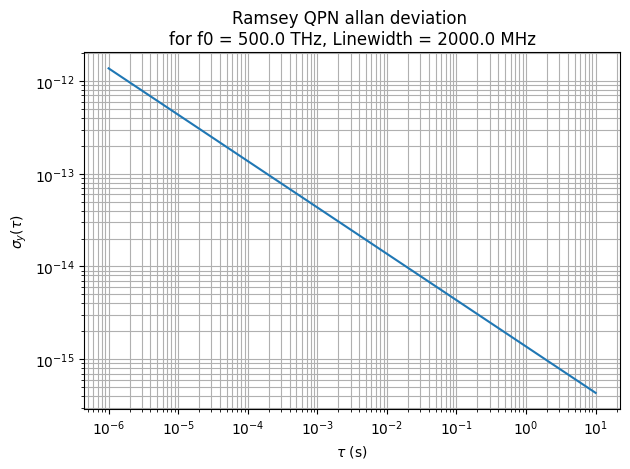

In [3]:
# custom
CHOSEN_F0 = 3
CHOSEN_DELTA_F = 6
f0_array = [193e12, 300e12, 400e12, 500e12]  # Hz
Delta_f_array = [300e3, 1e6, 30e6, 100e6, 300e6, 1e9, 2e9]  # Hz

f0 = f0_array[CHOSEN_F0]  # in Hz
Delta_f = Delta_f_array[CHOSEN_DELTA_F]  # in Hz (example value from fitted Lorentzian widths)

# for testing
# f0=
# Delta_f = gradient_distance * 1e6

# Delta_f =38.740e6  # in Hz (example value from fitted Lorentzian widths)
# f0=f_D12 # in Hz
T_m = 1/(2*np.pi*Delta_f / 2) # in seconds
# T_m = 0.5 / (Gamma_D2 / 2 + Gamma_tr_D2)
L_cell = 0.075   # meters (75 mm)
number = N * np.pi * (D_D1/2)**2 * L_cell   # number of atoms in interaction volume
print("center frequency f0 (THz):", f0/1e12)
print("linewidth Delta_f (MHz):", (Gamma_D2 / 2 + Gamma_tr_D2) / 1e6)
print("interaction time T_m (ns):", T_m * 1e9)
print("number of atoms in interaction volume:", number)

def sigma_y(tau):
    return (1/(2*np.pi*f0)) * np.sqrt(1/(2*number*T_m*tau))

# sigma_y against tau graph in us
# =======================
# Tau range (seconds)
# =======================
tau = np.logspace(-6, 1, 200)  # 1 us to 10 s

# =======================
# Plot
# =======================
plt.figure()
plt.loglog(tau, sigma_y(tau))
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Ramsey QPN allan deviation \nfor f0 = {f0/1e12} THz, Linewidth = {Delta_f/1e6} MHz')
plt.tight_layout()
plt.show()

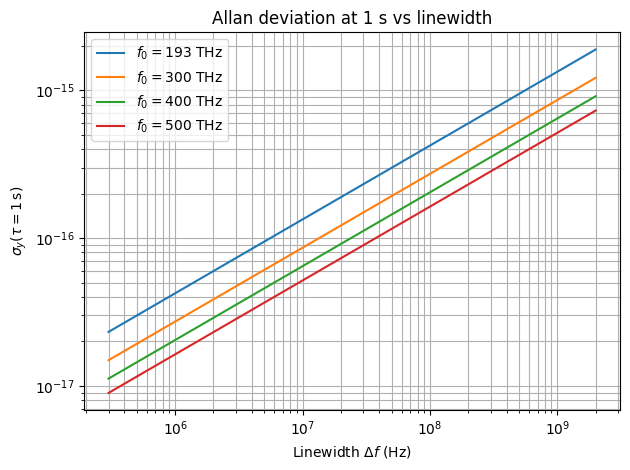

In [4]:
# custom: allan vs linewidth at fixed tau = 1s
tau_fixed = 1.0  # 1 second

# =======================
# Storage
# =======================
allan_vs_linewidth = []

# =======================
# Loop over f0
# =======================
for f0 in f0_array:

    sigma_y_1s = []

    for Delta_f in Delta_f_array:

        # Interaction time (your definition)
        T_m = 1 / (2 * np.pi * Delta_f / 2)

        # Number of atoms
        number = N * np.pi * (D_D2 / 2)**2 * L_cell

        # Allan deviation at tau = 1 s
        sigma = (1 / (2 * np.pi * f0)) * np.sqrt(
            1 / (2 * number * T_m * tau_fixed)
        )

        sigma_y_1s.append(sigma)

    allan_vs_linewidth.append(sigma_y_1s)

# =======================
# Plot
# =======================
plt.figure()

for i, f0 in enumerate(f0_array):
    plt.loglog(
        Delta_f_array,
        allan_vs_linewidth[i],
        label=fr'$f_0 = {f0/1e12:.0f}\ \mathrm{{THz}}$'
    )

plt.xlabel(r'Linewidth $\Delta f$ (Hz)')
plt.ylabel(r'$\sigma_y(\tau = 1\,\mathrm{s})$')
plt.title('Allan deviation at 1 s vs linewidth')
plt.legend()
plt.grid(True, which='both')
plt.tight_layout()
plt.show()


## Statistical noise
- Intensity-derived noise
    - photon detector noise
    - power supply noise
- Atom number-derived noise
    - quantum projection 
    - gas density
    - photon shot

### Probe intensity-derived noise - PD noise

Fitted L_cell : 0.1543 m
used L_cell values for plotting: [np.float64(0.154319054987502), np.float64(0.154319054987502), np.float64(0.154319054987502), np.float64(0.154319054987502)] m


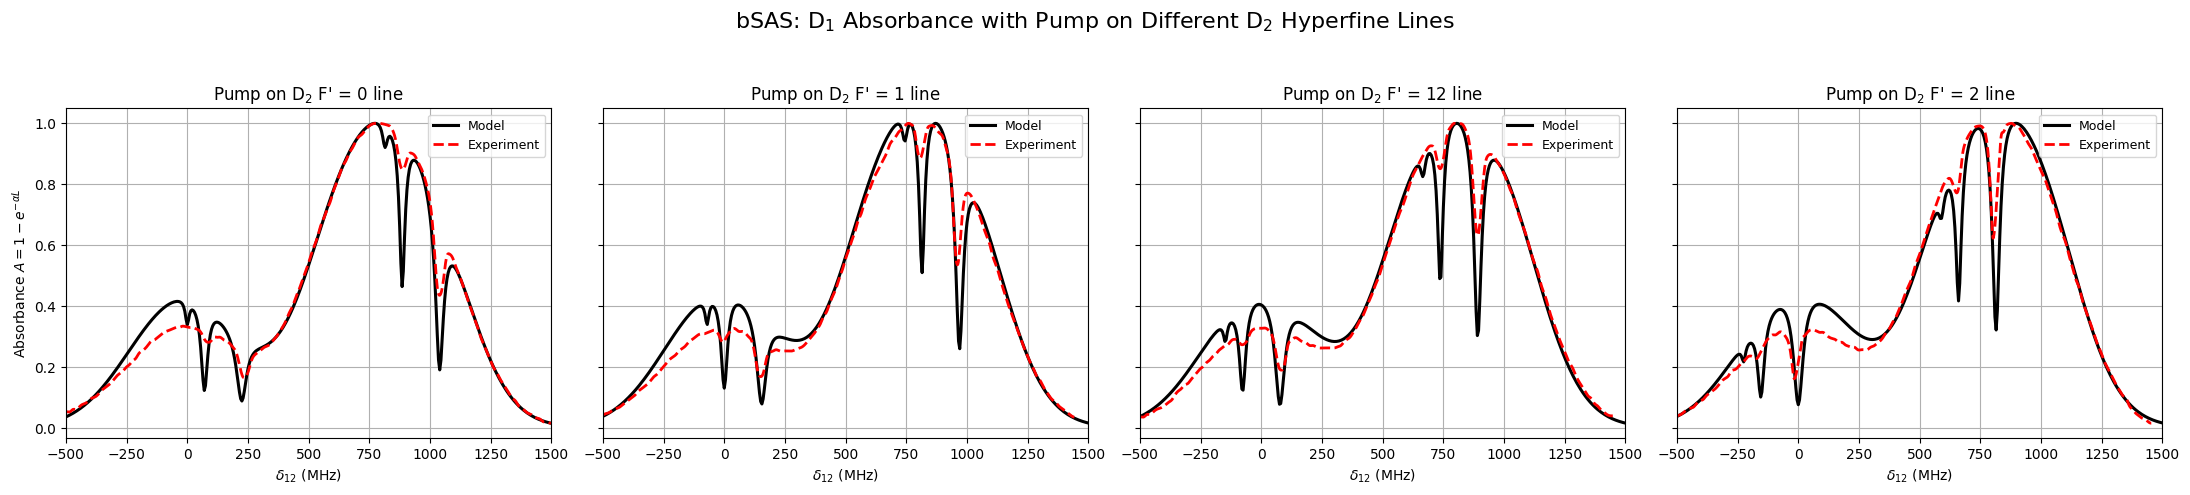

In [4]:
# finding L_cell

# import model_data
filename = "bSAS_alpha_output.txt"
model_data = np.loadtxt(filename, skiprows=1)  # skip header if present

pump_labels = [r"F' = 0", r"F' = 1", r"F' = 12", r"F' = 2"]
pump_freqs = [f_D20, f_D21, (f_D21+f_D22)/2, f_D22]   # Hz
pump_lambdas = [c/f for f in pump_freqs]  # m
delta_array_MHz = model_data[:, 0]
alpha_array = [model_data[:, 1], model_data[:, 2], model_data[:, 3], model_data[:, 4]]

# import exp data
exp_files = [
    "../fig_to_txt/genov bSAS eks F=0.csv",
    "../fig_to_txt/genov bSAS eks F=1.csv",
    "../fig_to_txt/genov bSAS eks F=12.csv",
    "../fig_to_txt/genov bSAS eks F=2.csv",
]
exp_data = [np.loadtxt(exp_files[i], delimiter=",") for i in range(len(exp_files))]
delta_exp = [data[:, 0] for data in exp_data]
A_exp = [data[:, 1] for data in exp_data]

# limit the data to delta_exp between -500 MHz and 1500 MHz
for i in range(len(pump_labels)):
    mask = (delta_exp[i] >= -500) & (delta_exp[i] <= 1500)
    delta_exp[i] = delta_exp[i][mask]
    A_exp[i] = A_exp[i][mask]

# fitting L_cell
L_cell_guess = 0.075  # initial guess in meters
L_cell_bounds = (0.01, 0.2)  # bounds for L_cell

# we fit L_cell to all pumps, so we need to concatenate the data
delta_array_MHz = np.array(delta_array_MHz)  # ensure it's a numpy array for interpolation
delta_array_MHz_conc = np.concatenate([delta_array_MHz + i * 2000 for i in range(len(pump_labels))])
alpha_array_conc = np.concatenate(alpha_array)

for i in range(len(pump_labels)):
    delta_exp[i] = np.array(delta_exp[i])  # ensure it's a numpy array for interpolation
delta_exp_conc = np.concatenate([delta_exp[i] + i * 2000 for i in range(len(pump_labels))])
for i in range(len(pump_labels)):
    A_exp[i] = A_exp[i] / np.max(A_exp[i])  # normalize to max of 1 for each pump
A_exp_conc = np.concatenate(A_exp)

alpha_interp = interp1d(delta_array_MHz_conc, alpha_array_conc, kind='linear')
def model_A_arr(delta, L_cell):
    A_arr = 1 - np.exp(-alpha_interp(delta) * L_cell)
    A_arr[:len(A_arr)//4] = A_arr[0:len(A_arr)//4] / np.max(A_arr[0:len(A_arr)//4])  # normalize to max of 1 for the first pump
    A_arr[len(A_arr)//4:len(A_arr)//2] = A_arr[len(A_arr)//4:len(A_arr)//2] / np.max(A_arr[len(A_arr)//4:len(A_arr)//2])  # normalize to max of 1 for the second pump
    A_arr[len(A_arr)//2:3*len(A_arr)//4] = A_arr[len(A_arr)//2:3*len(A_arr)//4] / np.max(A_arr[len(A_arr)//2:3*len(A_arr)//4])  # normalize to max of 1 for the third pump
    A_arr[3*len(A_arr)//4:] = A_arr[3*len(A_arr)//4:] / np.max(A_arr[3*len(A_arr)//4:])  # normalize to max of 1 for the fourth pump
    return A_arr

popt, _ = curve_fit(
    model_A_arr,
    delta_exp_conc,
    A_exp_conc,
    p0=[L_cell_guess],
    bounds=L_cell_bounds
)
L_cell_fit = popt[0]
print(f"Fitted L_cell : {popt[0]:.4f} m")

# L_cell_fit = []
# for i in range(len(pump_labels)):
#     # interpolate model alpha to match exp delta points
#     alpha_interp = interp1d(delta_array_MHz, alpha_array[i], kind='linear')
#     def model_A_arr(delta, L_cell):
#         A_arr = 1 - np.exp(-alpha_interp(delta) * L_cell)
#         return A_arr / np.max(A_arr)  # normalize to max of 1

#     popt, _ = curve_fit(
#         model_A_arr,
#         delta_exp[i],
#         A_exp[i] / np.max(A_exp[i]),
#         p0=[L_cell_guess],
#         bounds=L_cell_bounds
#     )
#     L_cell_fit.append(popt[0])
#     print(f"Fitted L_cell for {pump_labels[i]}: {popt[0]:.4f} m")

# plotting
# ===============================
# Figure: 1×4 panels
# ===============================
# L_cell_used = L_cell_fit
L_cell_used = [L_cell_fit for i in range(len(pump_labels))]  # use the same fitted L_cell for all pumps  
# L_cell_used = [0.1 for i in range(len(pump_labels))]  
print("used L_cell values for plotting:", L_cell_used,"m")
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for i, ax in enumerate(axes):
    def alpha_arr_to_A_arr(alpha_array, L_cell):
        A_arr = 1 - np.exp(-np.array(alpha_array) * L_cell)
        return A_arr / np.max(A_arr)  # normalize to max of 1

    # ---- Numerical model ----
    ax.plot(
        delta_array_MHz,
        alpha_arr_to_A_arr(alpha_array[i], L_cell_used[i]),
        "k",
        lw=2.2,
        label="Model"
    )

    # ---- Experimental data ----
    # normalize experimental trace (consistent with previous figures)
    A_exp[i] = A_exp[i] / np.max(A_exp[i])

    ax.plot(
        delta_exp[i],
        A_exp[i],
        "r--",
        lw=2.0,
        label="Experiment"
    )

    ax.set_title(fr"Pump on D$_2$ {pump_labels[i]} line")
    ax.set_xlabel(r"$\delta_{12}$ (MHz)")
    ax.set_xlim(-500, 1500)
    ax.grid(True)
    ax.legend(fontsize=9)

# Shared y-axis
axes[0].set_ylabel(r"Absorbance $A = 1 - e^{-\alpha L}$")

fig.suptitle(
    "bSAS: D$_1$ Absorbance with Pump on Different D$_2$ Hyperfine Lines",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

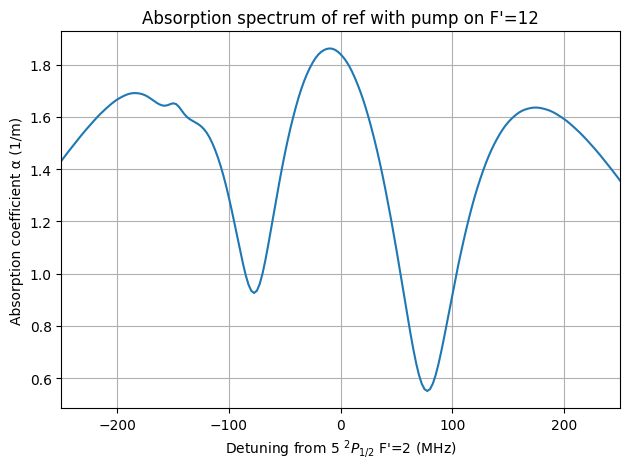

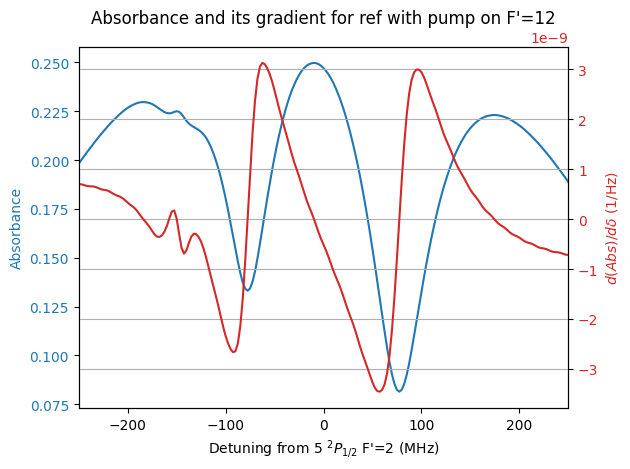

max gradient at detuning 95.00 MHz
min gradient at detuning 57.50 MHz
peak-to-peak gradient distance: 37.50 MHz
therefore, the laser should be modulated with frequency 18.75 MHz for optimal error signal generation
bellow is the plot of the error signal generated by modulating the laser at this frequency


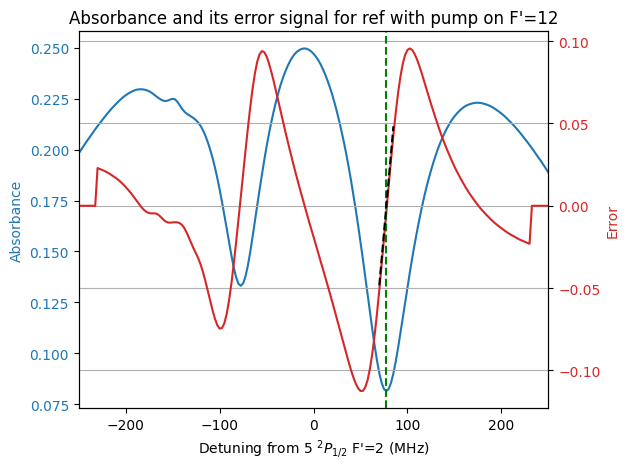

Zero-crossing detuning: 77.50 MHz
center detuning: 76.25 MHz
f0 = 377.112118 THz
dA/dDelta at zero-crossing: 6.44e-09 1/Hz


In [5]:
# Error characterization
# the ref data maker is on numeric.ipynb
L_cell = 0.1543  # m default is 75 mm, but the ref didn't list the value, so it is adjusted to fit the data

filedir = "bSAS_stabil_ref_output"
filename = "alpha.txt"
pump_labels = [r"F' = 12"]
pump_freqs = [(f_D21+f_D22)/2]   # Hz
pump_lambdas = [c/f for f in pump_freqs]  # m

data = np.loadtxt(os.path.join(filedir, filename), skiprows=1)   # skip header line

delta_array_MHz = np.array(data[:, 0])
alpha_array = [np.array(data[:, 1])]

# plot just the absorption from 12 pump, and zoom in on the lamb dip region
plt.figure()
plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, alpha_array[0], label=pump_labels[0])
plt.xlabel(r"Detuning from 5 $^2P_{1/2}$ F'=2 (MHz)")
plt.ylabel(r"Absorption coefficient α (1/m)")
plt.title('Absorption spectrum of ref with pump on F\'=12')
plt.xlim(-250, 250)  # zoom in on the Lamb dip region
plt.grid()
# plt.legend()
plt.tight_layout()
plt.show()

# and the absorbance with its gradient whose y-axis is on the right
Abs = 1.0 - np.exp(-alpha_array[0] * L_cell)
dAbs_dDelta = np.gradient(Abs, delta_array_MHz * 1e6)  # convert MHz to Hz for the gradient calculation
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel(r"Detuning from 5 $^2P_{1/2}$ F'=2 (MHz)")
ax1.set_ylabel(r"Absorbance", color=color)
ax1.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, Abs, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel(r"$d(Abs)/d\delta$ (1/Hz)", color=color)  # we already handled the x-label with ax1
ax2.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, dAbs_dDelta, color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.title('Absorbance and its gradient for ref with pump on F\'=12')
plt.xlim(-250, 250)  # zoom in on the Lamb dip region
plt.grid()
plt.tight_layout()
plt.show()

# finding the point of max gradient and min gradient, and their detuning distance, for delta > 0 (taking the right dip)
delta_mask = delta_array_MHz - f_p12F1_to_P12F2/1e6 > 0
max_gradient_index = np.argmax(dAbs_dDelta[delta_mask]) + np.where(delta_mask)[0][0]  # add the offset of the masked array
min_gradient_index = np.argmin(dAbs_dDelta[delta_mask]) + np.where(delta_mask)[0][0]  # add the offset of the masked array
print(f"max gradient at detuning {delta_array_MHz[max_gradient_index] - f_p12F1_to_P12F2/1e6:.2f} MHz")
print(f"min gradient at detuning {delta_array_MHz[min_gradient_index] - f_p12F1_to_P12F2/1e6:.2f} MHz")
max_gradient_detuning = delta_array_MHz[max_gradient_index] - f_p12F1_to_P12F2/1e6
min_gradient_detuning = delta_array_MHz[min_gradient_index] - f_p12F1_to_P12F2/1e6
gradient_distance = max_gradient_detuning - min_gradient_detuning
print(f"peak-to-peak gradient distance: {gradient_distance:.2f} MHz")

mod_frequency = gradient_distance / 2
print(f"therefore, the laser should be modulated with frequency {mod_frequency:.2f} MHz for optimal error signal generation")
print("bellow is the plot of the error signal generated by modulating the laser at this frequency")

# plot the absorbance with error signal from the modulation
def Abs_Error(x, delta_array_MHz, Abs, mod=mod_frequency):
    if(x - mod < delta_array_MHz[0] or x + mod> delta_array_MHz[-1]):
        return 0.0  # for out-of-bounds
    return np.interp(x + mod, delta_array_MHz, Abs) - np.interp(x - mod, delta_array_MHz, Abs)
Error = []
for x in delta_array_MHz:
    Error.append(Abs_Error(x, delta_array_MHz, Abs, mod=mod_frequency))  # taking the difference between Abs at f+mod_frequency and f-mod_frequency detuning points
Error = np.array(Error)

fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel(r"Detuning from 5 $^2P_{1/2}$ F'=2 (MHz)")
ax1.set_ylabel(r"Absorbance", color=color)
ax1.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, Abs, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel(r"Error", color=color)  # we already handled the x-label with ax1
ax2.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, Error, color=color)
ax2.tick_params(axis='y', labelcolor=color)
# marking the zero-crossing point of the error signal within the range of grad min and max
error_mask = (delta_array_MHz - f_p12F1_to_P12F2/1e6 > min_gradient_detuning) & (delta_array_MHz - f_p12F1_to_P12F2/1e6 < max_gradient_detuning)
zero_crossing_indices = np.where(np.diff(np.sign(Error[error_mask])))[0] + np.where(error_mask)[0][0]  # add the offset of the masked array
for idx in zero_crossing_indices:
    if min_gradient_detuning < delta_array_MHz[idx] - f_p12F1_to_P12F2/1e6 < max_gradient_detuning:
        plt.axvline(x=delta_array_MHz[idx] - f_p12F1_to_P12F2/1e6, color='green', linestyle='--', label='Zero-crossing point')
        break
# marking the tangent line at the zero-crossing point
tangent_slope = (Error[idx+1] - Error[idx-1]) / ((delta_array_MHz[idx+1] - delta_array_MHz[idx-1]) * 1e6)  # in 1/Hz
tangent_x = np.linspace(delta_array_MHz[idx] - (max_gradient_index - min_gradient_index)/2, delta_array_MHz[idx] + (max_gradient_index - min_gradient_index)/2, 100)
tangent_y = tangent_slope * 1e6 * (tangent_x - (delta_array_MHz[idx]))
plt.plot(tangent_x - f_p12F1_to_P12F2/1e6, tangent_y, color='black', linestyle='--', label='Tangent at zero-crossing')
plt.title('Absorbance and its error signal for ref with pump on F\'=12')
plt.xlim(-250, 250)  # zoom in on the Lamb dip region
plt.grid()
plt.tight_layout()
plt.show()
f0 = (delta_array_MHz[idx])*1e6 + f_D11  # convert MHz to Hz
print(f"Zero-crossing detuning: {delta_array_MHz[idx] - f_p12F1_to_P12F2/1e6:.2f} MHz")
print(f"center detuning: {(max_gradient_detuning + min_gradient_detuning)/2:.2f} MHz")
print(f"f0 = {f0/1e12:f} THz")
print(f"dA/dDelta at zero-crossing: {tangent_slope:.2e} 1/Hz")


Detection bandwidth: 10000.00 Hz


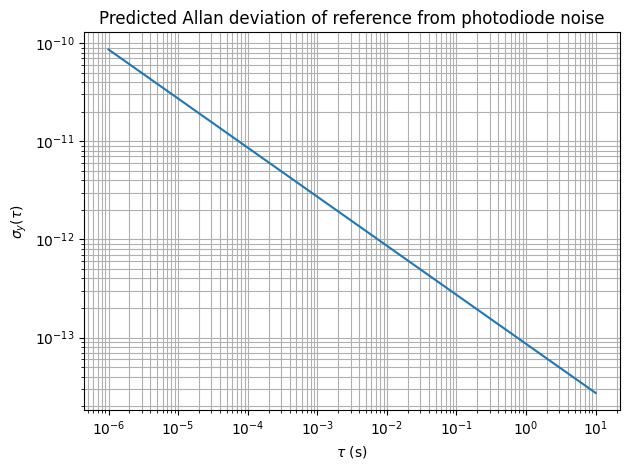

uncertainty f in 100 ms: 0.1033253039958329 kHz Normalized: 2.739909407969641e-13
ref uncertainty in 100 ms: 496 kHz Normalized: 1.3152587157234497e-09


In [6]:
# noise prediction
NEP = 3.1e-15   # from S5972 datasheet, in W/Hz^0.5, source https://octopart.com/datasheet/hamamatsu-photonics/S5972
# R_f = 50
# C_tot = 3e-12 # F, estimated total capaccitance if we only consider the photodetector capacitance 
# bandwidth = 1 / (2 * pi * R_f * C_tot)  # in Hz, where R_f and C_tot are the feedback resistor and total capacitance in the photodetector circuit
bandwidth = 10e3 # in Hz, assuming a detection bandwidth of 10 kHz for the error signal (this is a typical value for laser locking feedback loops using servo)
print(f"Detection bandwidth: {bandwidth:.2f} Hz")

I_pr_Wm2 = 0.04 * 6.2e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2
I_pr_W = I_pr_Wm2 * np.pi * (D_D1/2)**2  # in W, where D_D1 is the probe beam diameter in meters
I_pu_Wm2 = 6.2e-3  / 1e-4   # 1.3 mW/cm^2 -> W/m^2
I_pu_W = I_pu_Wm2 * np.pi * (D_D2/2)**2  # in W, where D_D2 is the pump beam diameter in meters
P_noise = NEP * np.sqrt(bandwidth * np.sqrt(2))  # detected intensity noise in 1 s, in W, where bandwidth is the detection bandwidth in Hz
A_noise = P_noise / I_pr_W  # normalized intensity noise in 1 s

tau = np.logspace(-6, 1, 200)  # 1 us to 10 s
sigma_y_f_int = 1/tangent_slope / f0 * A_noise / np.sqrt(2 * tau)  # fractional frequency instability due to intensity noise, where tangent_slope is the slope of the error signal at the locking point in 1/Hz, f0 is the optical frequency in Hz, A_noise is the normalized intensity noise in 1 s, and tau is the averaging time in seconds
# note: the factor of 2 in the denominator is because the allan deviation already include two variances from the two samples used in the difference calculation, so we need to divide by 2 to get the variance of each sample (assuming NEP is PSD under the common definition)
# ref: https://en.wikipedia.org/wiki/Noise-equivalent_power

plt.figure()
plt.loglog(tau, sigma_y_f_int, label='Predicted Allan deviation from photodiode noise')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation of reference from photodiode noise')
plt.tight_layout()
plt.show()

print("uncertainty f in 100 ms:", f0 * sigma_y_f_int[np.argmin(np.abs(tau - 0.1))] / 1e3, "kHz", "Normalized:", sigma_y_f_int[np.argmin(np.abs(tau - 0.1))])
print("ref uncertainty in 100 ms:", 496, "kHz", "Normalized:", 496e3/f0)

Detection bandwidth: 10000.00 Hz


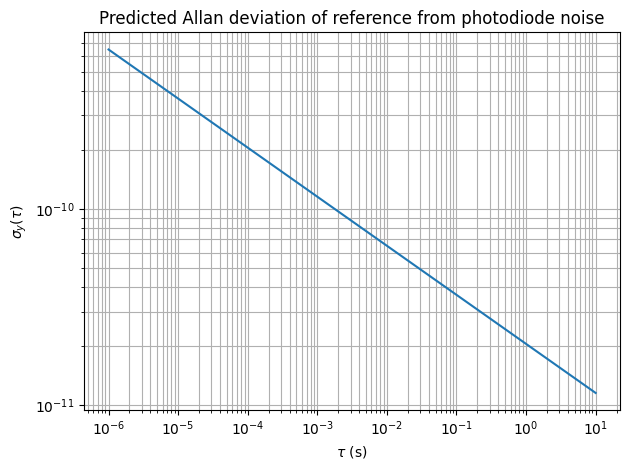

uncertainty f in 100 ms: 13.816175155232036 kHz Normalized: 3.66367838525821e-11
ref uncertainty in 100 ms: 496 kHz Normalized: 1.3152587157234497e-09


In [7]:
# noise prediction
NEP = 3.1e-15   # from S5972 datasheet, in W/Hz^0.5, source https://octopart.com/datasheet/hamamatsu-photonics/S5972
# R_f = 50
# C_tot = 3e-12 # F, estimated total capaccitance if we only consider the photodetector capacitance 
# bandwidth = 1 / (2 * pi * R_f * C_tot)  # in Hz, where R_f and C_tot are the feedback resistor and total capacitance in the photodetector circuit
bandwidth = 10e3 # in Hz, assuming a detection bandwidth of 10 kHz for the error signal (this is a typical value for laser locking feedback loops using servo)
print(f"Detection bandwidth: {bandwidth:.2f} Hz")

I_pr_Wm2 = 0.04 * 6.2e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2
I_pr_W = I_pr_Wm2 * np.pi * (D_D1/2)**2  # in W, where D_D1 is the probe beam diameter in meters
I_pu_Wm2 = 6.2e-3  / 1e-4   # 1.3 mW/cm^2 -> W/m^2
I_pu_W = I_pu_Wm2 * np.pi * (D_D2/2)**2  # in W, where D_D2 is the pump beam diameter in meters
P_noise = np.sqrt(NEP * I_pr_W * np.sqrt(2) / np.sqrt(2 * tau))
A_noise = P_noise / I_pr_W  # normalized intensity noise in 1 s

tau = np.logspace(-6, 1, 200)  # 1 us to 10 s
sigma_y_f_int = 1/tangent_slope / f0 * A_noise 
# note: the factor of 2 in the denominator is because the allan deviation already include two variances from the two samples used in the difference calculation, so we need to divide by 2 to get the variance of each sample (assuming NEP is PSD under the common definition)
# ref: https://en.wikipedia.org/wiki/Noise-equivalent_power

plt.figure()
plt.loglog(tau, sigma_y_f_int, label='Predicted Allan deviation from photodiode noise')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation of reference from photodiode noise')
plt.tight_layout()
plt.show()

print("uncertainty f in 100 ms:", f0 * sigma_y_f_int[np.argmin(np.abs(tau - 0.1))] / 1e3, "kHz", "Normalized:", sigma_y_f_int[np.argmin(np.abs(tau - 0.1))])
print("ref uncertainty in 100 ms:", 496, "kHz", "Normalized:", 496e3/f0)

### Probe intensity-derived noise - Shot noise

quantum efficiency eta: 0.89
Min abs: 0.1290, Max abs: 0.1174, Mean abs: 0.1232


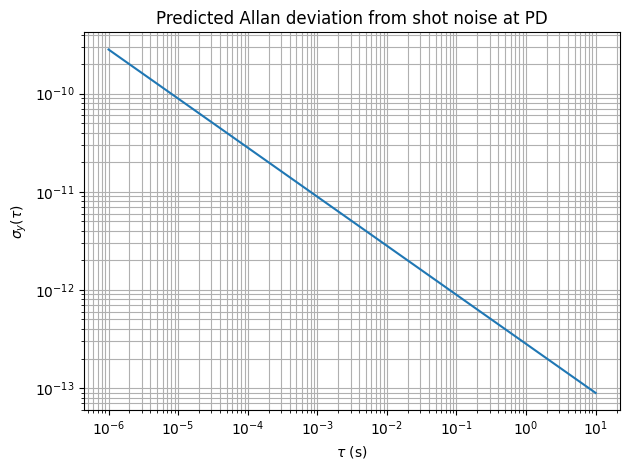

uncertainty f in 100 ms: 0.33828390250665247 kHz Normalized: 8.970380063726136e-13
ref uncertainty in 100 ms: 496 kHz Normalized: 1.3152587157234497e-09


In [9]:
photo_sens = 0.57  # A/W, from S5972 datasheet, at around 800 nm wavelength

I_pr_Wm2 = 0.04 * 6.2e-3 / 1e-4   # 0.03 mW/cm^2 -> W/m^2
Area =  np.pi * (D_D1/2)**2  # in W, where D_D1 is the probe beam diameter in meters

tau = np.logspace(-6, 1, 200)  # 1 us to 10 s
eta = h * f0 / e_charge * photo_sens
print(f"quantum efficiency eta: {eta:.2f}")
mean_Abs = (Abs[max_gradient_index] + Abs[min_gradient_index]) / 2
print(f"Min abs: {Abs[min_gradient_index]:.4f}, Max abs: {Abs[max_gradient_index]:.4f}, Mean abs: {mean_Abs:.4f}")
I_det = (1 - mean_Abs) * I_pr_Wm2
sigma_I_det = np.sqrt((eta * h * f0 * I_det) / (Area * tau))  
sigma_y_shot = np.sqrt(3) * sigma_I_det / (f0 * I_pr_Wm2 * np.abs(tangent_slope)) 

plt.figure()
plt.loglog(tau, sigma_y_shot, label='Predicted Allan deviation from shot noise at PD')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.grid(True, which='both')
plt.title(f'Predicted Allan deviation from shot noise at PD')
plt.tight_layout()
plt.show()

print("uncertainty f in 100 ms:", f0 * sigma_y_shot[np.argmin(np.abs(tau - 0.1))] / 1e3, "kHz", "Normalized:", sigma_y_shot[np.argmin(np.abs(tau - 0.1))])
print("ref uncertainty in 100 ms:", 496, "kHz", "Normalized:", 496e3/f0)

### Atom number-derived noise

In [8]:
# functions

def k_freq_from_lambda(lambda_m):
    return 1.0 / lambda_m

def mb_1d_pdf(v, u):
    """
    1D Maxwell-Boltzmann projection (normalized).
    v : array of velocities (m/s)
    u : most probable speed = sqrt(2 k_B T / m) (m/s)
    returns f_D(v; u)
    """
    return (1.0 / (u * np.sqrt(np.pi))) * np.exp(-(v**2) / (u**2))

def lorentzian_normalized(delta, Gamma_Hz):
    """
    Normalized Lorentzian (area = 1). Use when the formula expects a lineshape g_H(δ,Γ):
    g_H(delta, Gamma) = (1/pi) * ( (Gamma/2) / (delta^2 + (Gamma/2)^2) )
    Input: delta (Hz), Gamma_Hz (Hz)
    Output: s/Hz (integrates to 1 over delta)
    """
    return (1.0 / pi) * ( (Gamma_Hz / 2.0) / (delta**2 + (Gamma_Hz / 2.0)**2) )

def absorption_alpha_from_populations_v2(hbar, omega1j_rad, delta1j_Hz, k_freq, v_array, fD_v, Nj_pop, N1_pop, g_j, g1, Gamma_D1_Hz, B_1j):
    """
    Safer version: k_freq = 1/lambda (cycles/m); delta1j_Hz in Hz.
    Returns alpha (1/m).
    """
    # prefactor ℏ ω / c
    pref = (hbar * omega1j_rad) / c * B_1j

    # lineshape evaluated at (delta1j + k_freq * v) in Hz
    delta_v = delta1j_Hz + k_freq * v_array
    gH_vals = lorentzian_normalized(delta_v, Gamma_D1_Hz)   # units Hz^-1

    # integrand: fD(v) * gH( ... ) * (N1(v) - (g_j/g1) * N_j(v))
    # note: fD_v is omitted here because it's already included in N1_pop and Nj_pop
    integrand = gH_vals * (N1_pop - (g_j / g1) * Nj_pop)

    integral = np.trapz(integrand, v_array)   # integral over v (m/s), output units: (1/m/s) ??? combined pref fixes units
    alpha = pref * integral
    return alpha



# Electronic J values for D1 and D2 transitions
J_ground = 0.5
J_excited_D1 = 0.5   # P1/2
J_excited_D2 = 1.5   # P3/2

# degeneracies used in absorption prefactor
g1 = 2 * 1 + 1   # ground F=1 degeneracy = 3
g2 = 2 * 2 + 1   # ground F=2 degeneracy = 5
g3 = 2 * 1 + 1   # excited D1 F'=1 degeneracy = 3
g4 = 2 * 2 + 1   # excited D1 F'=2 degeneracy = 5
g5 = 2 * 0 + 1   # excited D2 F'=0 degeneracy = 1
g6 = 2 * 1 + 1   # excited D2 F'=1 degeneracy = 3
g7 = 2 * 2 + 1   # excited D2 F'=2 degeneracy =

def Bij_from_C11(omega_ij_rad, J_i, J_j, S_ij, GammaD_angular):
    """
    Compute the Einstein B_ij coefficient using Eq. (C11) form.
    Inputs:
      omega_ij_rad : transition angular frequency ω_ij (rad/s)
      J_i, J_j : total electronic J for initial and final (e.g., 1/2 or 3/2)
      S_ij : dimensionless line-strength factor (from ref; unitless)
      GammaD_angular : natural linewidth (angular) i.e., 2π * (Hz linewidth)
    Returns:
      B_ij in SI (m^3 / J / s) ???  (units consistent with I/c * gH)
    Note:
      Eq. (C11) in the paper shows Bij ∝ (1/3) c^3 π^2 / (ħ ω^3) * (2Jj+1)/(2Ji+1) * S_ij * ΓD.
      We implement that expression literally.
    """
    pref = (1.0/3.0) * (c**3) * (pi**2) / (hbar * (omega_ij_rad**3))
    factor = ((2.0 * J_j + 1.0) / (2.0 * J_i + 1.0))
    B_ij = pref * factor * S_ij * GammaD_angular * S_CONVENTION_CORRECTION
    return B_ij

def build_Bij_for_transitions(transitions_list):
    """
    transitions_list: list of dicts with keys:
       'f'   : transition frequency in Hz (omega/2pi)
       'lambda' : wavelength (m)
       'J_i', 'J_j' : electronic J initial and final
       'S_ij' : line strength factor S_{i->j} (dimensionless)
       'GammaD_Hz' : natural linewidth (Hz) appropriate for that line (D1 or D2)
    Returns: B_ij (float)
    """
    B_map = {}
    for tr in transitions_list:
        omega_rad = 2.0 * pi * tr['f']   # rad/s
        # appendix expects GammaD in angular units inside Bij pref:
        GammaD_angular = 2.0 * pi * tr['GammaD_Hz']
        B_map[tr['label']] = Bij_from_C11(omega_rad, tr['J_i'], tr['J_j'], tr['S_ij'], GammaD_angular)
    return B_map

# Define D1 probe transitions (j=3 and j=4)
transitions_D1 = [
    {'label': '1-3', 'f': f_D11, 'lambda': lambda_D11, 'J_i': J_ground, 'J_j': J_excited_D1, 'S_ij': S_coeff_D1_11, 'GammaD_Hz': Gamma_D1},
    {'label': '1-4', 'f': f_D12, 'lambda': lambda_D12, 'J_i': J_ground, 'J_j': J_excited_D1, 'S_ij': S_coeff_D1_12, 'GammaD_Hz': Gamma_D1},

    {'label': '3-1', 'f': f_D11, 'lambda': lambda_D11, 'J_i': J_excited_D1, 'J_j': J_ground, 'S_ij': S_coeff_D1_11 * (g1/g3), 'GammaD_Hz': Gamma_D1},
    {'label': '4-1', 'f': f_D12, 'lambda': lambda_D12, 'J_i': J_excited_D1, 'J_j': J_ground, 'S_ij': S_coeff_D1_12 * (g1/g4), 'GammaD_Hz': Gamma_D1},
]
B_map_D1 = build_Bij_for_transitions(transitions_D1)

def compute_bSAS_alpha_from_final_pop(delta_array_Hz,N1_v, N3_v, N4_v,
                                        v_max_factor=7.0, n_v=20001, verbose=True):
    """
    delta_array_Hz: 1D array of probe detunings (Hz) relative to f_D11 (the reference)
    N_total: total atomic density per m^3 (for the isotope)
    I_pr_Wm2, I_pu_Wm2: intensities
    Returns alpha_vs_detuning (1/m) array same length as delta_array_Hz
    """
    # build velocity grid and MB pdf
    v_max = v_max_factor * u
    v_grid = np.linspace(-v_max, v_max, n_v)
    fD_v = mb_1d_pdf(v_grid, u)  # normalized PDF


    alpha_array = np.zeros_like(delta_array_Hz)

    # precompute k_freq for probe transitions
    k13 = k_freq_from_lambda(lambda_D11)
    k14 = k_freq_from_lambda(lambda_D12)

    # loop over detunings
    for di, delta_hz in enumerate(delta_array_Hz):
        # For monochromatic SAS: pump detuning = probe detuning (scanning same source)
        probe_detuning_Hz = delta_hz

        # Now compute alpha for probe transitions j=3 and j=4 and sum (Eq. C12 summation over j=3,4)
        # prefactor uses ℏ ω1j / c. We'll compute separately and sum.
        omega_13_rad = 2.0 * pi * f_D11
        omega_14_rad = 2.0 * pi * f_D12

        # alpha for j=3
        alpha_13 = absorption_alpha_from_populations_v2(hbar, omega_13_rad, probe_detuning_Hz  - (f_D11 - f_D11),
                                                       k13, v_grid, fD_v, N3_v[di, :], N1_v[di, :],
                                                       g_j=2*1+1, g1=g1, Gamma_D1_Hz=Gamma_D1, B_1j=B_map_D1['1-3'])
        # alpha for j=4
        alpha_14 = absorption_alpha_from_populations_v2(hbar, omega_14_rad, probe_detuning_Hz - (f_D12 - f_D11),
                                                       k14, v_grid, fD_v, N4_v[di, :], N1_v[di, :],
                                                       g_j=2*2+1, g1=g1, Gamma_D1_Hz=Gamma_D1, B_1j=B_map_D1['1-4'])
        alpha_array[di] = alpha_13 + alpha_14

        # (optional) print progress
        if di % max(1, len(delta_array_Hz)//10) == 0 and verbose:
            print(f"bSAS: computed {di+1}/{len(delta_array_Hz)} detunings")

    return alpha_array




In [9]:
def find_delta_p(delta_array_MHz, Error_array, search_min, search_max):
    mask = (delta_array_MHz >= search_min) & (delta_array_MHz <= search_max)
    x = delta_array_MHz[mask]
    y = Error_array[mask]

    # find sign change
    idx = np.where(np.diff(np.sign(y)))[0]
    if len(idx) == 0:
        print("Notice: No zero-crossing found in the specified search range")
        return None

    i = idx[0]
    return np.interp(0, [y[i], y[i+1]], [x[i], x[i+1]])

def compute_error_signal(delta_array_Hz, N1_v, N3_v, N4_v, n_v=20001, verbose=True):
    alpha = compute_bSAS_alpha_from_final_pop(delta_array_Hz, N1_v, N3_v, N4_v, n_v=n_v, verbose=verbose)
    Abs = 1.0 - np.exp(-alpha * L_cell)   # if you already include length; else multiply by cell length L
    delta_array_MHz = delta_array_Hz / 1e6

    Error = np.array([Abs_Error(x, delta_array_MHz, Abs) for x in delta_array_MHz])
    return Abs, Error

def compute_gradient_delta_p(delta_array_Hz, N1_v, N3_v, N4_v,
                             search_min, search_max, eps=1e-5, n_v=20001, verbose=False):

    n_det, n_v = N1_v.shape
    grad = np.zeros(n_v)
    delta_array_MHz = delta_array_Hz / 1e6  # convert to MHz for find_delta_p

    # baseline delta_p
    Abs0, Err0 = compute_error_signal(delta_array_Hz, N1_v, N3_v, N4_v, n_v=n_v, verbose=verbose)
    delta_p0 = find_delta_p(delta_array_MHz, Err0, search_min, search_max)

    for vi in range(n_v):
        # relative perturbation
        dN = eps * np.mean(N1_v[:, vi])
        if dN == 0:
            print(f"Warning: zero population at velocity index {vi}, skipping gradient calculation for this point.")
            continue

        # + perturb
        N1_plus = N1_v.copy()
        N1_plus[:, vi] += dN
        _, Err_plus = compute_error_signal(delta_array_Hz, N1_plus, N3_v, N4_v, n_v=n_v, verbose=verbose)
        delta_p_plus = find_delta_p(delta_array_MHz, Err_plus, search_min, search_max)

        # - perturb
        N1_minus = N1_v.copy()
        N1_minus[:, vi] -= dN
        _, Err_minus = compute_error_signal(delta_array_Hz, N1_minus, N3_v, N4_v, n_v=n_v, verbose=verbose)
        delta_p_minus = find_delta_p(delta_array_MHz, Err_minus, search_min, search_max)

        # gradient
        grad[vi] = (delta_p_plus - delta_p_minus) / (2 * dN)

        if vi+1 % max(1, n_v//10) == 0:
            print(f"v index {vi}/{n_v}, grad={grad[vi]:.3e}")

    return grad, delta_p0

def compute_sigma_N1_QPN(v_grid, N1_v, N_total, Vol, tau_tr, tau):
    fD = mb_1d_pdf(v_grid, u)
    N_vi = N_total * fD
    rho11 = np.mean(N1_v, axis=0) / N_total

    sigma2 = N_vi / Vol * rho11 * (1 - rho11) * tau_tr / tau
    return sigma2

def compute_volume(D, L):
    return np.pi * (D/2)**2 * L

def compute_allan_QPN(f0, grad, sigma2_N1, tau_array):
    sigma2_freq = np.zeros_like(tau_array)

    for ti, tau in enumerate(tau_array):
        sigma2_N1_tau = sigma2_N1(tau)
        sigma2_freq[ti] = np.sum((grad**2) * sigma2_N1_tau)

    allan = np.sqrt(sigma2_freq) / f0
    return allan

In [10]:
# importing population data
filedir = "bSAS_stabil_ref_output"

filename = "alpha.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=1)   # skip header line
delta_array_MHz = np.array(data[:, 0])
delta_array_Hz = delta_array_MHz * 1e6
alpha_array = [np.array(data[:, 1])]

# initial population 
filename = "N1_0.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)   # no header line
N1_0 = np.array(data)

filename = "N2_0.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)   # no header line
N2_0 = np.array(data)

# final population
# lines for detunings while collumns for populations at different velocities
filename = "N1_v.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)   # no header line
N1_v = np.array(data)

filename = "N3_v.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)
N3_v = np.array(data)

filename = "N4_v.txt"
data = np.loadtxt(os.path.join(filedir, filename), skiprows=0)
N4_v = np.array(data)

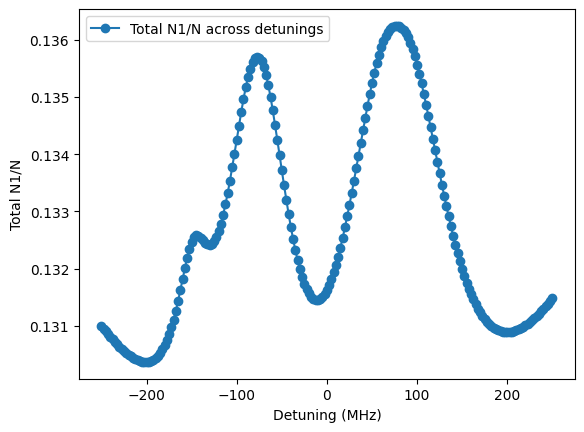

In [11]:
plt.figure()
plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, np.sum(N1_v, axis=1)/N, "o-", label=f"Total N1/N across detunings")
# plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, Err, "o-", label=f"N1(v_res) * {NRatioVal:.2f}")
# plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, N1_mod[:, v0_idx+i], "r", label=f"N1(v_res) * {NRatioVal:.2f}")
# plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, N1_mod[:, v0_idx+i+1], "b", label=f"N1(v_res) * {NRatioVal:.2f}")
plt.xlabel("Detuning (MHz)")
plt.ylabel("Total N1/N")
plt.legend()
plt.show()

searching for delta_p between 879.50 MHz and 902.00 MHz
baseline delta_p0: 892.16 MHz


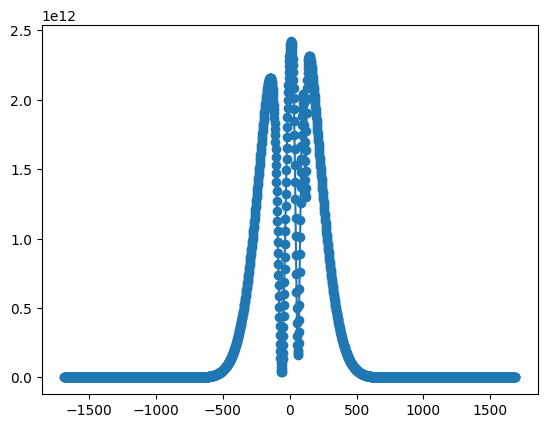

plotting at resonant velocity v0_idx = 964 v_grid[v0_idx] = -60.691600443734615 m/s


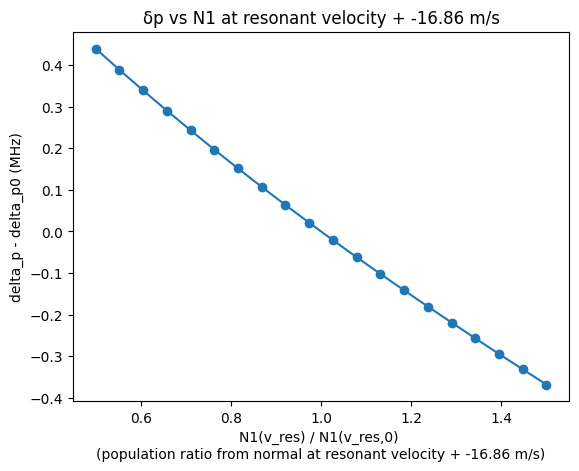

delta_p scan: [ 0.43990594  0.38908005  0.339435    0.29091956  0.24348535  0.19708664
  0.1516802   0.1072251   0.06368258  0.02101588 -0.02080985 -0.06182771
 -0.10206912 -0.14156396 -0.18051121 -0.21902372 -0.257046   -0.29458913
 -0.33166388 -0.36828068]


In [20]:
# plot delta_p vs population at v=resonance to see the sensitivity visually
v_max = 7*u
v_grid = np.linspace(-v_max, v_max, N1_v.shape[1])
delta_min_MHz = min_gradient_detuning + f_p12F1_to_P12F2/1e6
delta_max_MHz = max_gradient_detuning + f_p12F1_to_P12F2/1e6
print(f"searching for delta_p between {delta_min_MHz:.2f} MHz and {delta_max_MHz:.2f} MHz")

Abs0, Err0 = compute_error_signal(delta_array_Hz, N1_v, N3_v, N4_v, n_v=N1_v.shape[1], verbose=False)
delta_p0 = find_delta_p(delta_array_MHz, Err0, delta_min_MHz, delta_max_MHz)
print(f"baseline delta_p0: {delta_p0:.2f} MHz")

p0_idx = np.argmin(np.abs(delta_p0 - delta_array_MHz))
v0_idx = np.argmin(np.abs(N1_v[p0_idx, 850:1000])) + 850
plt.figure()
plt.plot( v_grid, N1_v[p0_idx, :], "o-", label=f"N1(v_res) * {1.0:.2f}")
plt.show()
print("plotting at resonant velocity v0_idx =", v0_idx, "v_grid[v0_idx] =", v_grid[v0_idx], "m/s")

N_ratio_scan = np.linspace(0.5, 1.5, 20) 
# N_ratio_scan = np.array([1.0 - 1e-12, 1.0, 1.0 + 1e-12])  # for testing extreme cases
delta_p_scan = []

i=-10 # shift the fluctuated velocity index by i
for NRatioVal in N_ratio_scan:
    N1_mod = N1_v.copy()
    N1_mod[:, v0_idx+i] *= NRatioVal
    _, Err = compute_error_signal(delta_array_Hz, N1_mod, N3_v, N4_v, n_v=N1_v.shape[1], verbose=False)
    # plt.figure()
    # plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, _, "o-", label=f"N1(v_res) * {NRatioVal:.2f}")
    # plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, Err, "o-", label=f"N1(v_res) * {NRatioVal:.2f}")
    # plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, N1_mod[:, v0_idx+i], "r", label=f"N1(v_res) * {NRatioVal:.2f}")
    # plt.plot(delta_array_MHz - f_p12F1_to_P12F2/1e6, N1_mod[:, v0_idx+i+1], "b", label=f"N1(v_res) * {NRatioVal:.2f}")
    # plt.show()
    delta_p_scan.append(find_delta_p(delta_array_MHz, Err, delta_min_MHz, delta_max_MHz))

plt.figure()
plt.plot(N_ratio_scan, np.array(delta_p_scan) - delta_p0, 'o-')
plt.xlabel(f"N1(v_res) / N1(v_res,0) \n(population ratio from normal at resonant velocity + {(v_grid[v0_idx+i] - v_grid[v0_idx]):.2f} m/s)")
plt.ylabel("delta_p - delta_p0 (MHz)")
plt.title(f"δp vs N1 at resonant velocity + {(v_grid[v0_idx+i] - v_grid[v0_idx]):.2f} m/s")
plt.show()
# plt.tight_layout()
print("delta_p scan:", np.array(delta_p_scan) - delta_p0)

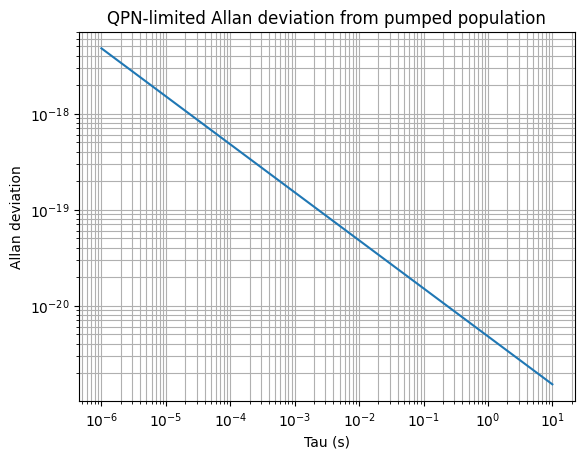

In [ ]:
tau_array = np.logspace(-6, 1, 200)

# velocity grid must match your population grid
v_max = 7*u
v_grid = np.linspace(-v_max, v_max, N1_v.shape[1])
vol = compute_volume(D_D1, L_cell)

delta_min_MHz = min_gradient_detuning + f_p12F1_to_P12F2/1e6
delta_max_MHz = max_gradient_detuning + f_p12F1_to_P12F2/1e6

grad, delta_p0 = compute_gradient_delta_p(delta_array_Hz, N1_v, N3_v, N4_v,
                                          search_min=delta_min_MHz, search_max=delta_max_MHz, n_v=N1_v.shape[1], verbose=False)

def sigma2_func(tau):
    return compute_sigma_N1_QPN(v_grid, N1_v, N, vol, 1/Gamma_tr_D2, tau)

allan = compute_allan_QPN(f0, grad, sigma2_func, tau_array)

plt.figure()
plt.loglog(tau_array, allan)
plt.xlabel("Tau (s)")
plt.ylabel("Allan deviation")
plt.title("QPN-limited Allan deviation from pumped population")
plt.grid(True, which="both")
plt.show()